In [2]:
import networkx as nx
import pandas as pd

bart = pd.read_csv(
    "../data/date-hour-soo-dest-2025.csv.gz",
    header=None
)
bart.columns = ["date", "hour", "origin", "destination", "trips"]
bart.head()
bart["date"] = pd.to_datetime(bart["date"])
# bart.groupby("origin")["trips"].sum().sort_values(ascending=False)
# bart.groupby("date")["trips"].sum().sort_values(ascending=False)
daily = bart.groupby("date")["trips"].sum()
# daily.index.day_name()
daily_mean = daily.groupby(daily.index.day_name()).mean()
daily_median = daily.groupby(daily.index.day_name()).median()

# print(daily_mean)
# print(daily_median)

daily = daily.reset_index()
daily["weekday"] = daily["date"].dt.day_name()

import matplotlib.pyplot as plt

weekdays = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_trips = [
    daily.loc[daily["weekday"] == day, "trips"]
    for day in weekdays
]

# plt.boxplot(weekday_trips, tick_labels=weekdays)
# plt.ylabel("Daily trips")
# plt.title("BART Daily Ridership by Day of Week, 2025")
# plt.xticks(rotation=45)
# plt.show()

# daily.sort_values("trips", ascending=True).head(15)
# daily.nsmallest(15, "trips")

daily_sunday = daily.loc[daily["weekday"] == "Sunday"]

# plt.plot(daily_sunday["date"], daily_sunday["trips"])
# plt.xlabel("Date")
# plt.ylabel("Daily trips")
# plt.title("BART Sunday Ridership, 2025")
# plt.xticks(rotation=45)
# plt.show()

# daily_sunday.loc[daily_sunday["trips"] == daily_sunday["trips"].max()]
daily_sunday.nlargest(1, "trips")

pride = bart.loc[bart["date"] == "2025-06-29"]

pride_dest = pride.groupby("destination")["trips"].sum().sort_values(ascending=False)

other_sundays = bart.loc[
    (bart["date"].dt.day_name() == "Sunday") &
    (bart["date"] != "2025-06-29")
]

sunday_destinations = (
    other_sundays.groupby(["date", "destination"])["trips"].sum()
)

sunday_baseline = sunday_destinations.groupby("destination").median()

pride_orig = pride.groupby("origin")["trips"].sum().sort_values(ascending=False)

other_sundays = bart.loc[
    (bart["date"].dt.day_name() == "Sunday") &
    (bart["date"] != "2025-06-29")
]

sunday_origins = (
    other_sundays.groupby(["date", "origin"])["trips"].sum()
)

sunday_origins_baseline = sunday_origins.groupby("origin").median()

In [3]:
import pandas as pd
import networkx as nx
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import adjusted_rand_score

bart = pd.read_csv(
    "../data/date-hour-soo-dest-2025.csv.gz",
    header=None
)
bart.columns = ["date", "hour", "origin", "destination", "trips"]
bart.head()
bart["date"] = pd.to_datetime(bart["date"])

edges = bart.groupby(['origin', 'destination'])['trips'].sum()
edges = edges.reset_index()
edges = edges.loc[edges["origin"] != edges["destination"]]

G = nx.from_pandas_edgelist(
    edges,
    source='origin',
    target='destination',
    edge_attr='trips',
    create_using=nx.DiGraph
)

out_strength = dict(G.out_degree(weight="trips"))
in_strength = dict(G.in_degree(weight="trips"))

station_flow = pd.DataFrame({
    "out": pd.Series(out_strength),
    "in": pd.Series(in_strength),
})

station_flow['net'] = station_flow['out'] - station_flow['in']
station_flow['imbalance'] = (station_flow['out'] - station_flow['in']) / (station_flow['out'] + station_flow['in'])

# print('Smallest Net', station_flow.nsmallest(10, "net"))
# print('Largest Net', station_flow.nlargest(10, "net"))
# print('Smallest Imbalance', station_flow.nsmallest(10, "imbalance"))
# print('Largest Imbalance', station_flow.nlargest(10, "imbalance"))

origin = edges.loc[edges["origin"] == "16TH"].copy()
origin[["destination", "trips"]].sort_values("trips", ascending=False)
origin["p"] = origin["trips"] / origin["trips"].sum()

H = -(origin["p"] * np.log(origin["p"])).sum()
normalized_H = H / np.log(len(origin))

def normalized_entropy(group):
    p = group["trips"] / group["trips"].sum()
    return -(p * np.log(p)).sum() / np.log(len(group))

entropy_by_station = (
    edges.groupby("origin")
    .apply(normalized_entropy)
    .sort_values()
)

# woak = edges.loc[edges["origin"] == "WOAK"].copy()
#
# woak["share"] = woak["trips"] / woak["trips"].sum()
#
# woak.nlargest(10, "share")

flow_matrix = edges.pivot(
    index="origin",
    columns="destination",
    values="trips"
)

flow_matrix = flow_matrix.fillna(0)
flow_matrix_norm = flow_matrix / flow_matrix.sum(axis=1)

# orin = flow_matrix_norm.loc["ORIN"]
# lafy = flow_matrix_norm.loc["LAFY"]
# sfia = flow_matrix_norm.loc["SFIA"]
#
# np.linalg.norm(orin - sfia)

distances = pd.DataFrame(
    squareform(pdist(flow_matrix_norm, metric="euclidean")),
    index=flow_matrix_norm.index,
    columns=flow_matrix_norm.index
)

Z = linkage(flow_matrix_norm, method="ward")

# plt.figure(figsize=(14, 8))
#
# dendrogram(
#     Z,
#     labels=flow_matrix_norm.index
# )

# plt.ylabel("Distance")
# plt.title("BART Stations Clustered by Destination Patterns")
# plt.show()

clusters = fcluster(
    Z,
    t=0.3,
    criterion="distance"
)

station_clusters = pd.DataFrame({
    "station": flow_matrix_norm.index,
    "cluster": clusters
})

station_clusters.sort_values(["cluster", "station"])
station_clusters.groupby("cluster")["station"].apply(list)

# for cluster, group in station_clusters.groupby("cluster"):
#     print(cluster, group["station"].tolist())

flow_with_cluster = flow_matrix_norm.copy()
flow_with_cluster["cluster"] = clusters

cluster_profiles = flow_with_cluster.groupby("cluster").mean()

# print(cluster_profiles.loc[5].sort_values(ascending=False).head(10))
# print(cluster_profiles.loc[6].sort_values(ascending=False).head(10))
comparison_clusters = (5, 6)
if all(cluster in cluster_profiles.index for cluster in comparison_clusters):
    cluster_diff = (
        cluster_profiles.loc[comparison_clusters[0]]
        - cluster_profiles.loc[comparison_clusters[1]]
    )
else:
    cluster_diff = None

# print(cluster_diff.sort_values())

G_undirected = nx.Graph()

for u, v, data in G.edges(data=True):
    weight = data["trips"]

    if G_undirected.has_edge(u, v):
        G_undirected[u][v]["weight"] += weight
    else:
        G_undirected.add_edge(u, v, weight=weight)

communities = nx.community.louvain_communities(
    G_undirected,
    weight="weight",
    seed=42
)

# for i, community in enumerate(communities, start=1):
#     print(i, sorted(community))

def community_labels(communities, nodes):
    labels = {}

    for i, community in enumerate(communities):
        for node in community:
            labels[node] = i

    return [labels[node] for node in nodes]

nodes = sorted(G_undirected.nodes())

reference = nx.community.louvain_communities(
    G_undirected,
    weight="weight",
    seed=42
)

reference_labels = community_labels(reference, nodes)

for seed in range(10):
    c = nx.community.louvain_communities(
        G_undirected,
        weight="weight",
        seed=seed
    )

    labels = community_labels(c, nodes)

    print(
        seed,
        adjusted_rand_score(reference_labels, labels)
    )

0 1.0
1 0.9168702497285559
2 0.774376216598832
3 0.9168702497285559
4 0.9168702497285559
5 0.774376216598832
6 0.774376216598832
7 0.6645238472736708
8 0.5658936094814349
9 0.774376216598832


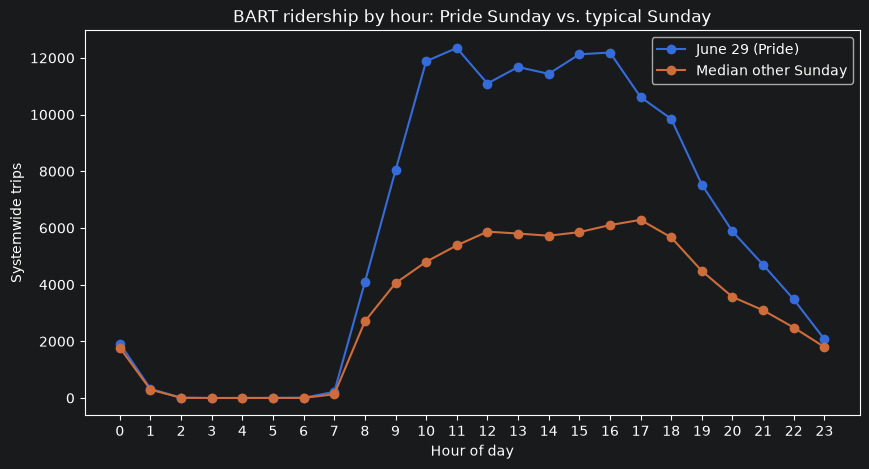

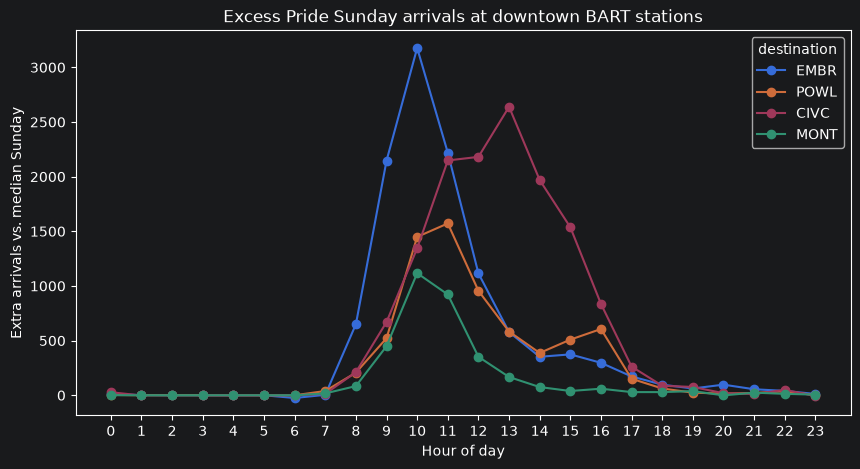

In [5]:
pride_hourly = (
    pride
    .groupby("hour")["trips"]
    .sum()
)

other_sunday_hourly = (
    other_sundays
    .groupby(["date", "hour"])["trips"].sum()
)

typical_sunday_hourly = other_sunday_hourly.groupby(level="hour").median()

hourly_comparison = pd.concat(
    [pride_hourly, typical_sunday_hourly],
    axis=1
)

hourly_comparison = hourly_comparison.sort_index()
hourly_comparison.columns = ["pride", "typical_sunday"]
hourly_comparison["pride"] = hourly_comparison["pride"].fillna(0)
hourly_comparison["difference"] = (
    hourly_comparison["pride"]
    - hourly_comparison["typical_sunday"]
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    hourly_comparison.index,
    hourly_comparison["pride"],
    marker="o",
    label="June 29 (Pride)"
)

ax.plot(
    hourly_comparison.index,
    hourly_comparison["typical_sunday"],
    marker="o",
    label="Median other Sunday"
)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Systemwide trips")
ax.set_title("BART ridership by hour: Pride Sunday vs. typical Sunday")
ax.set_xticks(range(24))
ax.legend()

plt.show()

pride_hourly_dest = (
    pride
    .groupby(["hour", "destination"])["trips"].sum()
)

other_sunday_hourly_dest = (
    other_sundays
    .groupby(["date", "hour", "destination"])["trips"]
    .sum()
)

typical_sunday_hourly_dest = (
    other_sunday_hourly_dest.groupby(level=["hour", "destination"]).median()
)

pride_10am_dest = pride_hourly_dest.xs(10, level="hour")

dest_difference_10am = (
    pride_10am_dest
    - typical_sunday_hourly_dest.xs(10, level="hour")
)

# dest_difference_10am.sort_values(ascending=False).head(10)

hourly_dest_difference = (
    pride_hourly_dest
    - typical_sunday_hourly_dest
).fillna(0)

top_dest_by_hour = (
    hourly_dest_difference
    .groupby(level="hour")
    .idxmax()
)

top_value_by_hour = (
    hourly_dest_difference
    .groupby(level="hour")
    .max()
)

top_hourly_destinations = pd.DataFrame({
    "destination": top_dest_by_hour.apply(lambda x: x[1]),
    "extra_arrivals": top_value_by_hour
})

downtown_difference = (
    hourly_dest_difference
    .unstack("destination")
)

downtown_difference = downtown_difference[
    ["EMBR", "POWL", "CIVC", "MONT"]
]

fig, ax = plt.subplots(figsize=(10, 5))

downtown_difference.plot(
    ax=ax,
    marker="o"
)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Extra arrivals vs. median Sunday")
ax.set_title("Excess Pride Sunday arrivals at downtown BART stations")
ax.set_xticks(range(24))

plt.show()